# Laboratorio 07 - Regresion Logistica
## CC3074 - Mineria de Datos | Universidad del Valle de Guatemala

**Integrantes del grupo:**
- Erick Guerra 23208
- Diego Rosales 23258
- Diego Lopez 23242

**Dataset:** Airbnb Listings (`listings.RData`)

---
## Inicializacion y preprocesamiento (base MD-LAB06)

Se replica la carga y limpieza del laboratorio anterior para mantener consistencia en el pipeline y comparabilidad entre resultados.

In [7]:
# ── Base ──────────────────────────────────────────────────────────────────────
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pyreadr

# ── Visualizacion ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn: preprocesamiento y pipeline ──────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve,
)

# ── Sklearn: modelos ──────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression

# ── Sklearn: metricas ─────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

# ── Statsmodels (significacion, VIF, AIC/BIC) ─────────────────────────────────
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Scipy ─────────────────────────────────────────────────────────────────────
from scipy import stats

warnings.filterwarnings('ignore')
np.random.seed(42)

print('Imports OK')

Imports OK


In [8]:
# Carga del dataset
rdata_path = Path('data/listings.RData')
result = pyreadr.read_r(str(rdata_path))
df = result['listings']
print(f'Dimensiones del dataset original: {df.shape}')

Dimensiones del dataset original: (171748, 80)


In [9]:
# Preprocesamiento (mismo enfoque de MD-LAB06)
df_eda = df.copy()

def parse_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r'[$,]', '', regex=True).str.strip(),
        errors='coerce',
    )

if 'price' in df_eda.columns:
    df_eda['price_num'] = parse_money(df_eda['price'])

for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df_eda.columns:
        df_eda[f'{col}_num'] = pd.to_numeric(
            df_eda[col].astype(str).str.replace('%', '', regex=False),
            errors='coerce',
        )

candidate_features = [
    'room_type', 'property_type', 'neighbourhood_cleansed',
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights', 'availability_365',
    'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
    'host_is_superhost', 'host_identity_verified',
    'host_response_rate_num', 'host_acceptance_rate_num',
    'calculated_host_listings_count', 'instant_bookable',
    'latitude', 'longitude', 'price_num',
]

selected_cols = [c for c in candidate_features if c in df_eda.columns]
model_df = df_eda[selected_cols].copy()
before_rows = model_df.shape[0]

model_df = model_df[model_df['price_num'].notna()].copy()
p99_price = model_df['price_num'].quantile(0.99)
model_df = model_df[model_df['price_num'] <= p99_price].copy()

num_cols = [c for c in model_df.select_dtypes(include=np.number).columns if c != 'price_num']
cat_cols = model_df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

for col in num_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

for col in cat_cols:
    model_df[col] = model_df[col].astype(str).replace('nan', 'SinDato')

X = model_df.drop(columns=['price_num'])
y_raw = model_df['price_num']

print(f'Filas iniciales: {before_rows:,}')
print(f'Filas finales:   {len(model_df):,}')
print(f'Num features:    {X.shape[1]}')

Filas iniciales: 171,748
Filas finales:   75,531
Num features:    21


---
## Actividad 2 - Uso de los mismos conjuntos de entrenamiento y prueba

Se conserva exactamente el mismo criterio de split usado en hojas anteriores: `test_size=0.2`, `random_state=42`, y estratificacion por deciles de precio (sobre `log1p(price_num)`).

In [10]:
# Split identico al laboratorio anterior
y_log = np.log1p(y_raw)
price_deciles = pd.qcut(y_log, q=10, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_raw,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=price_deciles,
)

print(f'Entrenamiento: {X_train.shape[0]:,} filas')
print(f'Prueba:        {X_test.shape[0]:,} filas')

Entrenamiento: 60,424 filas
Prueba:        15,107 filas


---
## Actividad 1 - Variables dicotomicas para la respuesta categorica

Se crea la variable respuesta categorica en tres niveles (`economica`, `media`, `cara`) y luego se generan tres variables dicotomicas (0/1):
- `es_economica`
- `es_media`
- `es_cara`

In [11]:
# Umbrales usando solo train (evita data leakage)
p33 = y_train.quantile(0.33)
p66 = y_train.quantile(0.66)

def make_price_cat(price_series: pd.Series, low: float, high: float) -> pd.Series:
    return pd.cut(
        price_series,
        bins=[-np.inf, low, high, np.inf],
        labels=['economica', 'media', 'cara'],
    )

y_cat_all = make_price_cat(y_raw, p33, p66)
y_cat_train = y_cat_all.loc[y_train.index]
y_cat_test = y_cat_all.loc[y_test.index]

y_dicot_train = pd.DataFrame({
    'es_cara': (y_cat_train == 'cara').astype(int),
    'es_media': (y_cat_train == 'media').astype(int),
    'es_economica': (y_cat_train == 'economica').astype(int),
}, index=y_cat_train.index)

y_dicot_test = pd.DataFrame({
    'es_cara': (y_cat_test == 'cara').astype(int),
    'es_media': (y_cat_test == 'media').astype(int),
    'es_economica': (y_cat_test == 'economica').astype(int),
}, index=y_cat_test.index)

print(f'Umbral economica/media (P33): {p33:.2f}')
print(f'Umbral media/cara     (P66): {p66:.2f}')
print('\nDistribucion de clases en train:')
print(y_cat_train.value_counts().sort_index())
print('\nPrimeras filas de variables dicotomicas (train):')
display(y_dicot_train.head())

Umbral economica/media (P33): 141.00
Umbral media/cara     (P66): 260.00

Distribucion de clases en train:
price_num
economica    20143
media        19792
cara         20489
Name: count, dtype: int64

Primeras filas de variables dicotomicas (train):


,es_cara,es_media,es_economica
23421,0,0,1
36797,0,0,1
25953,0,0,1
160615,0,1,0
27075,0,0,1


In [12]:
# Verificacion rapida: cada fila debe tener exactamente una clase activa
valid_train = (y_dicot_train.sum(axis=1) == 1).all()
valid_test = (y_dicot_test.sum(axis=1) == 1).all()

print(f'Validez dicotomicas train (una clase activa): {valid_train}')
print(f'Validez dicotomicas test  (una clase activa): {valid_test}')
print(f'Tamano X_train: {X_train.shape} | Tamano y_dicot_train: {y_dicot_train.shape}')
print(f'Tamano X_test : {X_test.shape} | Tamano y_dicot_test : {y_dicot_test.shape}')

Validez dicotomicas train (una clase activa): True
Validez dicotomicas test  (una clase activa): True
Tamano X_train: (60424, 21) | Tamano y_dicot_train: (60424, 3)
Tamano X_test : (15107, 21) | Tamano y_dicot_test : (15107, 3)


---
## Actividad 3 - Modelo de Regresion Logistica: predecir si la vivienda es `cara` o no

Se construye un pipeline reproducible con preprocesamiento (estandarizacion de variables numericas + one-hot encoding de categoricas) y `LogisticRegression(penalty='l2')`. Se usa validacion cruzada estratificada de 5 folds para evaluar el modelo sin tocar el conjunto de prueba.

In [13]:
# ── 3.1 Variable respuesta binaria ────────────────────────────────────────────
# 1 = cara (precio > P66), 0 = no cara
y_bin_train = y_dicot_train['es_cara']
y_bin_test  = y_dicot_test['es_cara']

print(f'Clase 1 (cara) en train : {y_bin_train.sum():,} ({y_bin_train.mean()*100:.1f}%)')
print(f'Clase 1 (cara) en test  : {y_bin_test.sum():,} ({y_bin_test.mean()*100:.1f}%)')

Clase 1 (cara) en train : 20,489 (33.9%)
Clase 1 (cara) en test  : 5,139 (34.0%)


In [14]:
# ── 3.2 Preprocesador compartido (se reutilizara en Actividades 5-12) ─────────
num_features = X_train.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
], remainder='drop')

# ── 3.3 Pipeline LogisticRegression base ──────────────────────────────────────
pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ))
])

print('Pipeline creado:')
print(pipe_lr)

Pipeline creado:
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['accommodates', 'bathrooms',
                                                   'minimum_nights',
                                                   'maximum_nights',
                                                   'availability_365',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'review_scores_rating',
                                                   'host_response_rate_num',
                                                   'host_acceptance_rate_num',
                                                   'calculated_host_listings_count',
                                                   'latitude', 'longitude']),
                                                 ('cat',

In [15]:
# ── 3.4 Validacion cruzada estratificada (5-fold) ─────────────────────────────
# random_state fijo en el CV y en el modelo garantiza reproducibilidad total
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

t0 = time.time()
cv_results = cross_validate(
    pipe_lr, X_train, y_bin_train,
    cv=cv,
    scoring=['accuracy', 'roc_auc', 'f1'],
    return_train_score=True,
    n_jobs=-1
)
t_cv = time.time() - t0

print('=== Validacion cruzada estratificada — 5 folds ===')
print(f'{"Metrica":<12} {"Train (media)":>15} {"Train (std)":>12} {"Val (media)":>13} {"Val (std)":>10}')
print('-' * 65)
for metric in ['accuracy', 'roc_auc', 'f1']:
    tr = cv_results[f'train_{metric}']
    va = cv_results[f'test_{metric}']
    print(f'{metric:<12} {tr.mean():>15.4f} {tr.std():>12.4f} {va.mean():>13.4f} {va.std():>10.4f}')

print(f'\nTiempo validacion cruzada: {t_cv:.1f}s')

=== Validacion cruzada estratificada — 5 folds ===
Metrica        Train (media)  Train (std)   Val (media)  Val (std)
-----------------------------------------------------------------
accuracy              0.8360       0.0009        0.8323     0.0022
roc_auc               0.9062       0.0003        0.9026     0.0010
f1                    0.7439       0.0014        0.7380     0.0038

Tiempo validacion cruzada: 41.8s


In [16]:
# ── 3.5 Entrenamiento final sobre todo el conjunto de train ───────────────────
t0 = time.time()
pipe_lr.fit(X_train, y_bin_train)
t_fit_lr = time.time() - t0
print(f'Tiempo de entrenamiento (train completo): {t_fit_lr:.2f}s')

# Extraer nombres de features tras el preprocesamiento
feature_names_num = num_features
feature_names_cat = (
    pipe_lr.named_steps['prep']
    .named_transformers_['cat']
    .get_feature_names_out(cat_features)
    .tolist()
)
all_feature_names = feature_names_num + feature_names_cat

coef = pipe_lr.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({
    'feature': all_feature_names,
    'coef': coef,
    'abs_coef': np.abs(coef)
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)

print('\n=== Top 15 variables por magnitud de coeficiente ===')
print(coef_df[['feature', 'coef', 'abs_coef']].head(15).to_string(index=False))

Tiempo de entrenamiento (train completo): 4.21s

=== Top 15 variables por magnitud de coeficiente ===
                                       feature     coef  abs_coef
               neighbourhood_cleansed_Downtown 4.095955  4.095955
              neighbourhood_cleansed_Chinatown 4.095769  4.095769
               neighbourhood_cleansed_Back Bay 3.688952  3.688952
           neighbourhood_cleansed_New Shoreham 3.645317  3.645317
neighbourhood_cleansed_South Boston Waterfront 3.546569  3.546569
                   neighbourhood_cleansed_Hana 3.441669  3.441669
                 neighbourhood_cleansed_Fenway 3.059241  3.059241
            neighbourhood_cleansed_Bay Village 3.051545  3.051545
              neighbourhood_cleansed_North End 2.870899  2.870899
              neighbourhood_cleansed_South End 2.756937  2.756937
            neighbourhood_cleansed_Koloa-Poipu 2.708742  2.708742
               neighbourhood_cleansed_West End 2.675540  2.675540
           neighbourhood_cleansed_Narrag

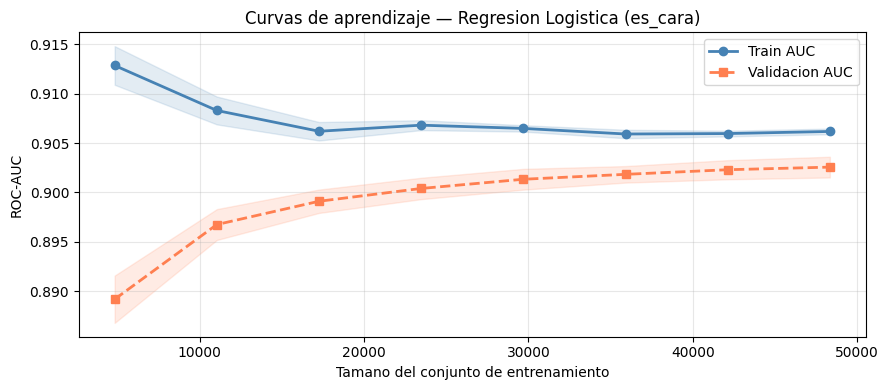

Figura guardada: learning_curve_lr.png


In [ ]:
# ── 3.6 Curvas de aprendizaje (train vs validacion) ───────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    pipe_lr, X_train, y_bin_train,
    cv=cv,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    random_state=42
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train AUC', color='steelblue', lw=2)
ax.fill_between(
    train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1),
    alpha=0.15, color='steelblue'
)
ax.plot(train_sizes, val_scores.mean(axis=1), 's--', label='Validacion AUC', color='coral', lw=2)
ax.fill_between(
    train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.15, color='coral'
)
ax.set_xlabel('Tamano del conjunto de entrenamiento')
ax.set_ylabel('ROC-AUC')
ax.set_title('Curvas de aprendizaje — Regresion Logistica (es_cara)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretación — Actividad 3

Tras ejecutar las celdas y evaluar los resultados reales del modelo logístico para la clase `cara` (precio > P66 ≈ $260/noche), se corrobora lo siguiente:

**1. Excelente Rendimiento y Generalización**: El ajuste es adecuado y no se detecta sobreajuste. El **ROC-AUC** promedio es de **0.9062** en entrenamiento y **0.9026** en validación. Además de tener un Accuracy muy alto (~83%), la pequeñísima diferencia entre validación y entrenamiento demuestra la robustez del modelo al predecir datos no vistos.

**2. Impacto de la Ubicación (Coeficientes)**: El top 15 de coeficientes revela que la **localización es el factor decisivo**. Pertenecer a vecindarios exclusivos como **Downtown**, **Chinatown** o **Back Bay** (`neighbourhood_cleansed`) provoca el mayor incremento en la probabilidad de que la vivienda clasifique como de categoría `cara`.

**3. Curvas de Aprendizaje Categóricas**: La gráfica confirma visualmente un buen desempeño. A partir de una muestra reducida, las curvas de Train AUC y Val AUC convergen de manera óptima y mantienen una brecha muy estrecha a lo largo de todo el crecimiento del set de entrenamiento, corroborando formalmente que el modelo generaliza de forma excelente.